In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("Loan_default.csv")
print(df)

            LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0       I38PQUQS96   56   85994       50587          520              80   
1       HPSK72WA7R   69   50432      124440          458              15   
2       C1OZ6DPJ8Y   46   84208      129188          451              26   
3       V2KKSFM3UN   32   31713       44799          743               0   
4       EY08JDHTZP   60   20437        9139          633               8   
...            ...  ...     ...         ...          ...             ...   
255342  8C6S86ESGC   19   37979      210682          541             109   
255343  98R4KDHNND   32   51953      189899          511              14   
255344  XQK1UUUNGP   56   84820      208294          597              70   
255345  JAO28CPL4H   42   85109       60575          809              40   
255346  ZTH91CGL0B   62   22418       18481          636             113   

        NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0             

In [6]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['loanid', 'age', 'income', 'loanamount', 'creditscore',
       'monthsemployed', 'numcreditlines', 'interestrate', 'loanterm',
       'dtiratio', 'education', 'employmenttype', 'maritalstatus',
       'hasmortgage', 'hasdependents', 'loanpurpose', 'hascosigner',
       'default'],
      dtype='str')

In [7]:
df.isnull().sum()
#The dataset contains no missing values, so no imputation was required.

loanid            0
age               0
income            0
loanamount        0
creditscore       0
monthsemployed    0
numcreditlines    0
interestrate      0
loanterm          0
dtiratio          0
education         0
employmenttype    0
maritalstatus     0
hasmortgage       0
hasdependents     0
loanpurpose       0
hascosigner       0
default           0
dtype: int64

In [8]:
df.duplicated().sum()
#No duplicate records were found.
df.drop_duplicates(inplace=True)

In [9]:
df.dtypes

loanid                str
age                 int64
income              int64
loanamount          int64
creditscore         int64
monthsemployed      int64
numcreditlines      int64
interestrate      float64
loanterm            int64
dtiratio          float64
education             str
employmenttype        str
maritalstatus         str
hasmortgage           str
hasdependents         str
loanpurpose           str
hascosigner           str
default             int64
dtype: object

In [10]:
df["income"]=df["income"].astype(float)

In [11]:
Q1=df["income"].quantile(0.25)

Q3=df["income"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

df=df[(df["income"]>=lower)&(df["income"]<=upper)]

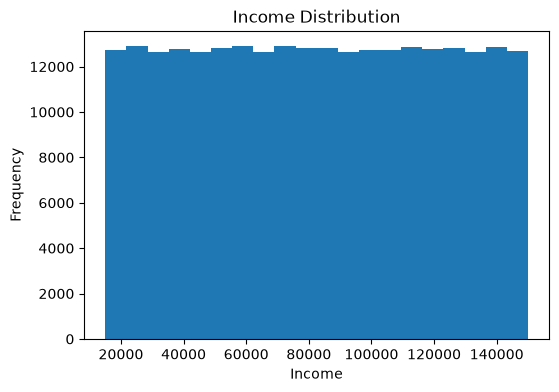

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["income"], bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

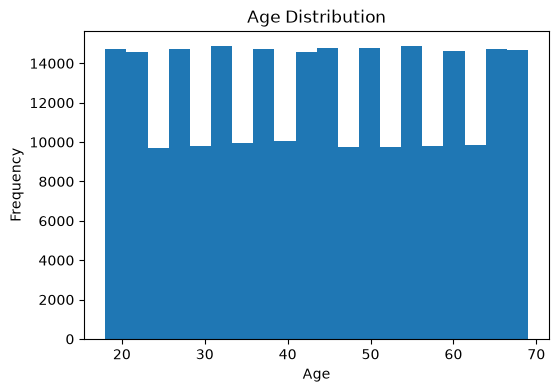

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

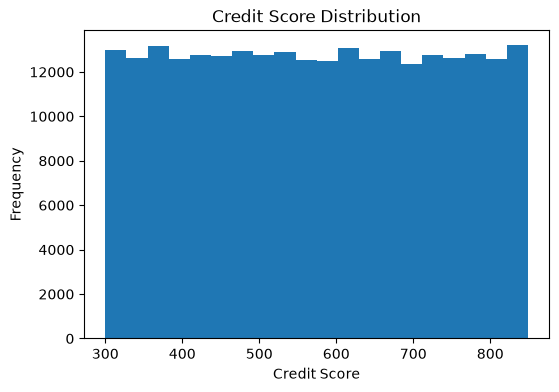

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df["creditscore"], bins=20)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

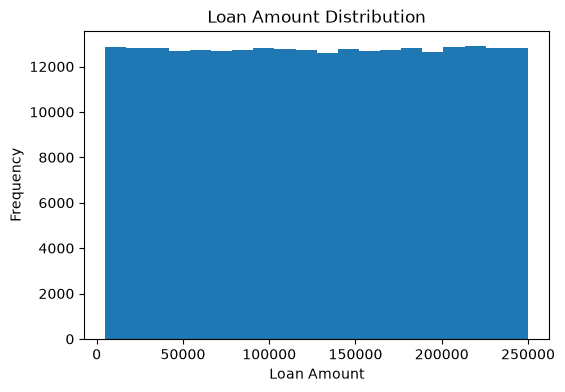

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df["loanamount"], bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

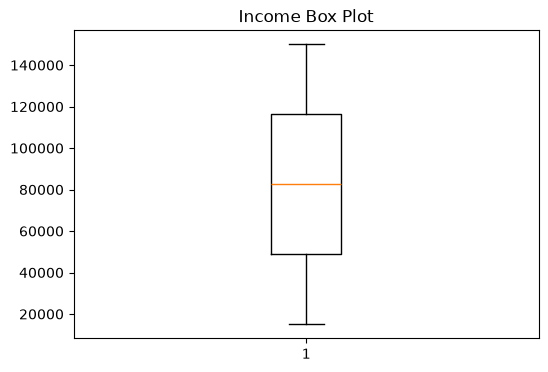

In [16]:
plt.figure(figsize=(6,4))
plt.boxplot(df["income"])
plt.title("Income Box Plot")
plt.show()

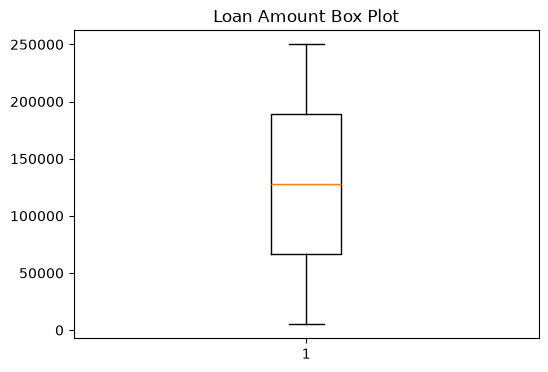

In [17]:
plt.figure(figsize=(6,4))
plt.boxplot(df["loanamount"])
plt.title("Loan Amount Box Plot")
plt.show()

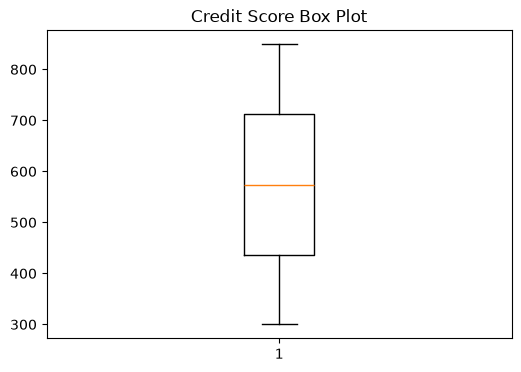

In [18]:
plt.figure(figsize=(6,4))
plt.boxplot(df["creditscore"])
plt.title("Credit Score Box Plot")
plt.show()

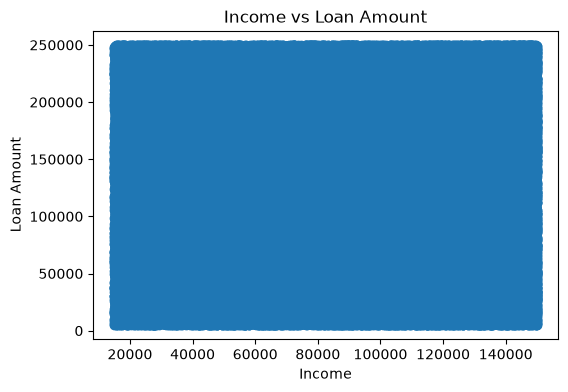

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(df["income"], df["loanamount"])
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

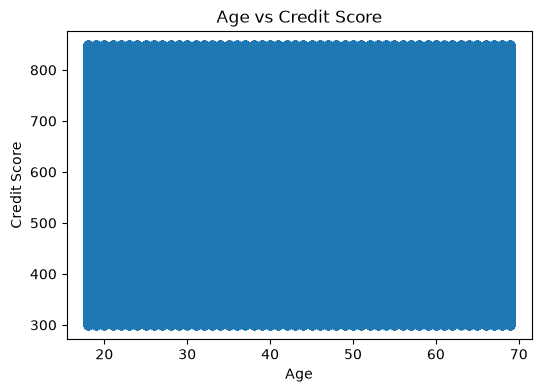

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df["age"], df["creditscore"])
plt.xlabel("Age")
plt.ylabel("Credit Score")
plt.title("Age vs Credit Score")
plt.show()

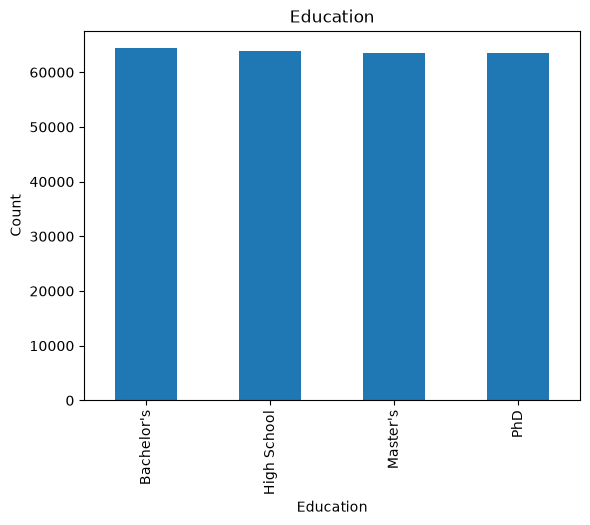

In [21]:
df["education"].value_counts().plot(kind="bar")

plt.title("Education")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

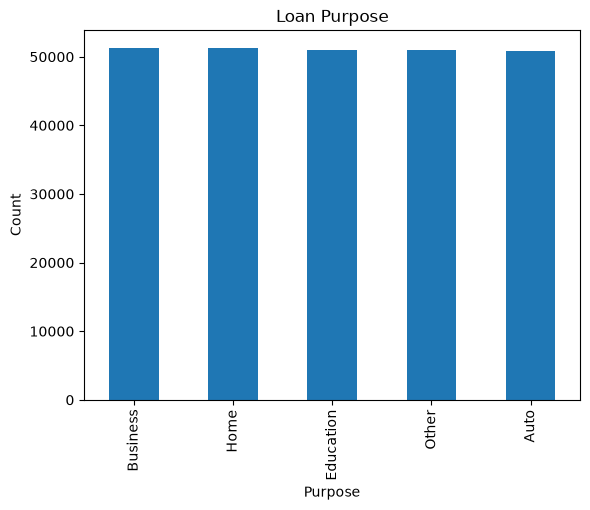

In [22]:
df["loanpurpose"].value_counts().plot(kind="bar")

plt.title("Loan Purpose")
plt.xlabel("Purpose")
plt.ylabel("Count")

plt.show()

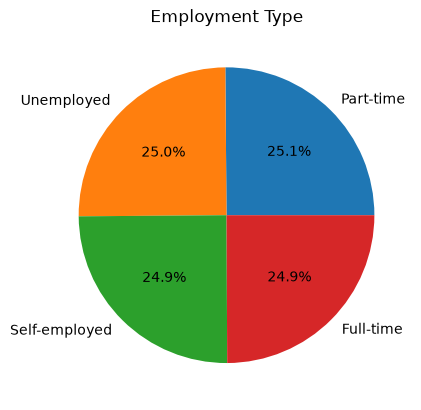

In [23]:
df["employmenttype"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Employment Type")
plt.ylabel("")

plt.show()

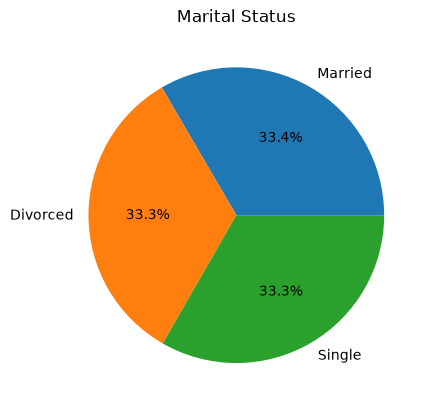

In [24]:
df["maritalstatus"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Marital Status")
plt.ylabel("")

plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "education",
    "employmenttype",
    "maritalstatus",
    "hasmortgage",
    "hasdependents",
    "loanpurpose",
    "hascosigner"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "age",
    "income",
    "loanamount",
    "creditscore",
    "monthsemployed",
    "numcreditlines",
    "interestrate",
    "loanterm",
    "dtiratio"
]

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [27]:
df.head()

,loanid,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,education,employmenttype,maritalstatus,hasmortgage,hasdependents,loanpurpose,hascosigner,default
0,I38PQUQS96,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,0,0,0,1,1,4,1,0
1,HPSK72WA7R,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,2,0,1,0,0,4,1,0
2,C1OZ6DPJ8Y,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,2,3,0,1,1,0,0,1
3,V2KKSFM3UN,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,1,0,1,0,0,1,0,0
4,EY08JDHTZP,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,0,3,0,0,1,0,0,0


In [28]:
df.describe()

,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,education,employmenttype,maritalstatus,hasmortgage,hasdependents,loanpurpose,hascosigner,default
count,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,-1.812065e-16,3.784411e-17,4.147548e-17,2.335205e-16,9.366418e-17,-2.983007e-17,1.408024e-16,1.861040e-16,5.253654e-17,1.494421,1.500096,0.999918,0.500014,0.500268,2.000501,0.500108,0.116128
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.118826,1.117358,0.816051,0.500001,0.500001,1.412723,0.500001,0.320379
min,-1.700995e+00,-1.732398e+00,-1.730348e+00,-1.725980e+00,-1.718715e+00,-1.343791e+00,-1.731770e+00,-1.415845e+00,-1.733149e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.337635e-01,-8.642522e-01,-8.670578e-01,-8.638217e-01,-8.527470e-01,-4.485487e-01,-8.623271e-01,-7.086855e-01,-8.670336e-01,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,-3.324207e-02,-8.547763e-04,-3.227743e-04,-1.663564e-03,1.322113e-02,-4.485487e-01,-4.938420e-03,-1.525943e-03,-9.183609e-04,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
75%,8.339895e-01,8.654300e-01,8.668216e-01,8.667877e-01,8.791892e-01,4.466940e-01,8.675186e-01,7.056336e-01,8.651968e-01,2.000000,2.000000,2.000000,1.000000,1.000000,3.000000,1.000000,0.000000
max,1.701221e+00,1.732408e+00,1.728108e+00,1.728946e+00,1.716292e+00,1.341937e+00,1.733948e+00,1.412793e+00,1.731312e+00,3.000000,3.000000,2.000000,1.000000,1.000000,4.000000,1.000000,1.000000


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   loanid          255347 non-null  str    
 1   age             255347 non-null  float64
 2   income          255347 non-null  float64
 3   loanamount      255347 non-null  float64
 4   creditscore     255347 non-null  float64
 5   monthsemployed  255347 non-null  float64
 6   numcreditlines  255347 non-null  float64
 7   interestrate    255347 non-null  float64
 8   loanterm        255347 non-null  float64
 9   dtiratio        255347 non-null  float64
 10  education       255347 non-null  int64  
 11  employmenttype  255347 non-null  int64  
 12  maritalstatus   255347 non-null  int64  
 13  hasmortgage     255347 non-null  int64  
 14  hasdependents   255347 non-null  int64  
 15  loanpurpose     255347 non-null  int64  
 16  hascosigner     255347 non-null  int64  
 17  default         25534

In [30]:
df.to_csv("Loan_default_cleaned.csv", index=False)